# **M2 - Initial Implementation**
## **Discovering Latent Musical Structure Using Spotify Audio Features**

This notebook implements Milestone 2 of the CS 4412 Data Mining project.  
The goal is to perform deep exploratory data analysis (EDA), apply justified preprocessing decisions, and implement an initial clustering model to discover latent musical patterns in Spotify audio features.

This milestone builds upon feedback from M1 by:
- Providing precise dataset details
- Quantifying data quality issues
- Including multiple visualizations
- Justifying preprocessing decisions
- Evaluating clustering with metrics
- Interpreting discovered patterns


**Research Questions**

- Do natural groupings of songs exist based on Spotify audio features?

- Which audio features most strongly differentiate discovered clusters?

- What patterns exist between clusters and emotional or structural attributes?

The following analysis addresses these questions.

In [7]:
import os
os.listdir('/content/drive/MyDrive/CS4412_Project/')

['SpotifyAudioFeaturesApril2019.csv',
 'SpotifyAudioFeaturesNov2018.csv',
 'Spotify_Tracks_Dataset.csv']

### **Dataset Overview**

The dataset originally contains 114,000 tracks and 21 columns.

After removing duplicate observations and non-informative columns, the final dataset contains 113,550 tracks and 20 variables.

It includes numeric audio features such as:
- danceability (0–1)
- energy (0–1)
- valence (0–1)
- loudness (measured in dB)
- tempo (beats per minute)
- duration_ms

In addition to metadata such as:
- track name
- artist
- popularity
- explicit content indicator

The dataset is publicly available on Kaggle:
https://www.kaggle.com/datasets/maharshipandya/-spotify-tracks-dataset

In [8]:
# DataSet OverView

from google.colab import drive
drive.mount('/content/drive')

import pandas as pd

df = pd.read_csv('/content/drive/MyDrive/CS4412_Project/Spotify_Tracks_Dataset.csv')

df.shape

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


(114000, 21)

In [9]:
df.info()
df.isnull().sum()
df.duplicated().sum()
df.describe()


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 114000 entries, 0 to 113999
Data columns (total 21 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        114000 non-null  int64  
 1   track_id          114000 non-null  object 
 2   artists           113999 non-null  object 
 3   album_name        113999 non-null  object 
 4   track_name        113999 non-null  object 
 5   popularity        114000 non-null  int64  
 6   duration_ms       114000 non-null  int64  
 7   explicit          114000 non-null  bool   
 8   danceability      114000 non-null  float64
 9   energy            114000 non-null  float64
 10  key               114000 non-null  int64  
 11  loudness          114000 non-null  float64
 12  mode              114000 non-null  int64  
 13  speechiness       114000 non-null  float64
 14  acousticness      114000 non-null  float64
 15  instrumentalness  114000 non-null  float64
 16  liveness          11

,Unnamed: 0,popularity,duration_ms,danceability,energy,key,loudness,mode,speechiness,acousticness,instrumentalness,liveness,valence,tempo,time_signature
count,114000.000000,114000.000000,1.140000e+05,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000,114000.000000
mean,56999.500000,33.238535,2.280292e+05,0.566800,0.641383,5.309140,-8.258960,0.637553,0.084652,0.314910,0.156050,0.213553,0.474068,122.147837,3.904035
std,32909.109681,22.305078,1.072977e+05,0.173542,0.251529,3.559987,5.029337,0.480709,0.105732,0.332523,0.309555,0.190378,0.259261,29.978197,0.432621
min,0.000000,0.000000,0.000000e+00,0.000000,0.000000,0.000000,-49.531000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,28499.750000,17.000000,1.740660e+05,0.456000,0.472000,2.000000,-10.013000,0.000000,0.035900,0.016900,0.000000,0.098000,0.260000,99.218750,4.000000
50%,56999.500000,35.000000,2.129060e+05,0.580000,0.685000,5.000000,-7.004000,1.000000,0.048900,0.169000,0.000042,0.132000,0.464000,122.017000,4.000000
75%,85499.250000,50.000000,2.615060e+05,0.695000,0.854000,8.000000,-5.003000,1.000000,0.084500,0.598000,0.049000,0.273000,0.683000,140.071000,4.000000
max,113999.000000,100.000000,5.237295e+06,0.985000,1.000000,11.000000,4.532000,1.000000,0.965000,0.996000,1.000000,1.000000,0.995000,243.372000,5.000000


In [10]:
## Data Quality Assessment

missing_percent = df.isnull().mean() * 100
missing_percent.sort_values(ascending=False)

,0
artists,0.000877
track_name,0.000877
album_name,0.000877
Unnamed: 0,0.000000
track_id,0.000000
popularity,0.000000
duration_ms,0.000000
explicit,0.000000
danceability,0.000000
energy,0.000000


The maximum missing value percentage across all features is 0.000877%, corresponding to only one missing entry out of 114,000 observations. Since this proportion is negligible (<0.001%), no imputation is required and all rows are retained.

Importantly, all numerical audio features used for clustering contain 0% missing values. The limited missing values occur only in metadata fields (artist, album name, track name) and therefore do not affect modeling.

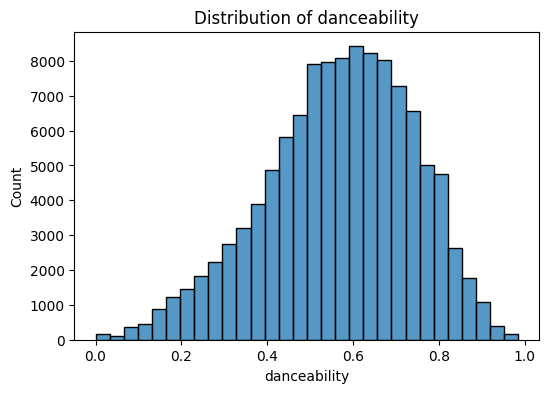

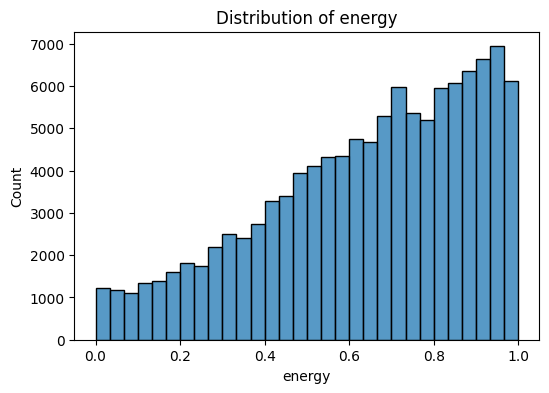

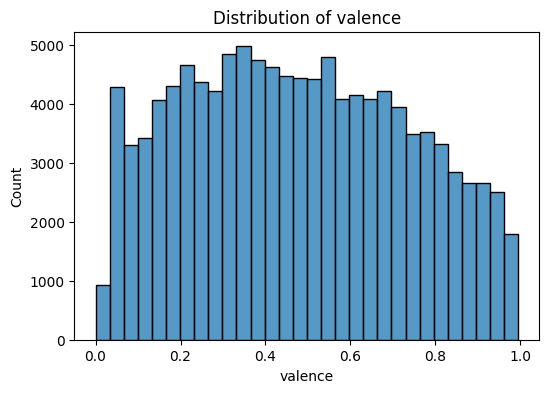

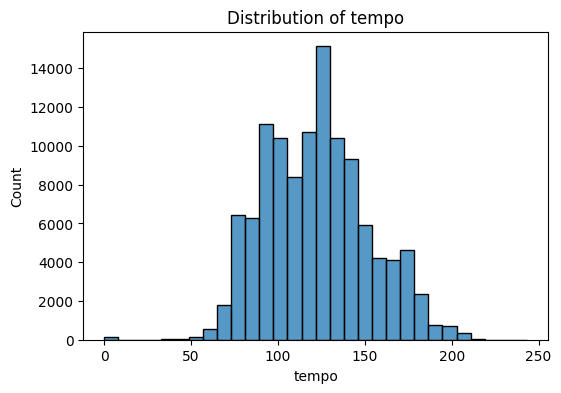

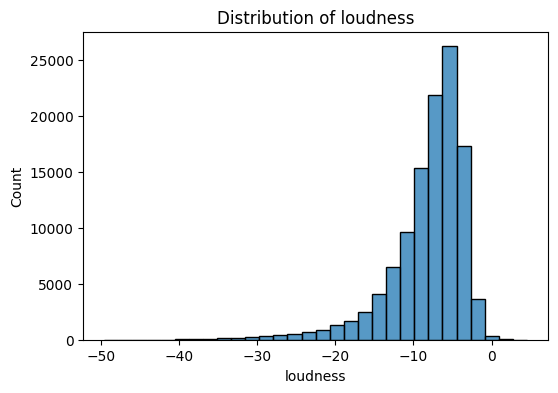

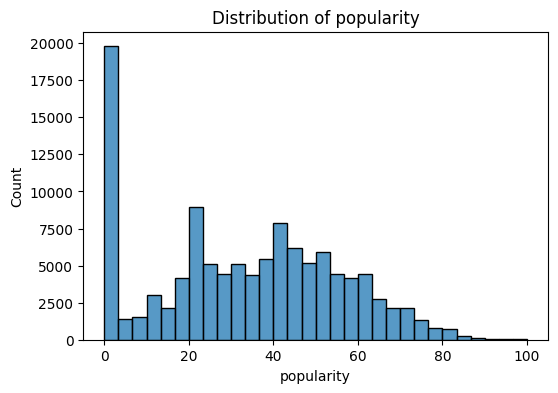

In [11]:
# A - Feature Distribution

import matplotlib.pyplot as plt
import seaborn as sns

features = ['danceability','energy','valence','tempo','loudness','popularity']

for feature in features:
    plt.figure(figsize=(6,4))
    sns.histplot(df[feature], bins=30)
    plt.title(f"Distribution of {feature}")
    plt.show()

## **A - Feature Distribution Interpretation**

### **Danceability**
- The distribution of danceability appears approximately unimodal with slight right skew, centered around 0.5 - 0.7. This suggests that most songs in the dataset are reasonably danceable, with very few extremely low or extremely high values.

### **Energy**
- Energy exhibits a negatively skewed distribution, with a higher concentration of tracks in the 0.6–1.0 range. This indicates the dataset contains a large proportion of energetic songs, potentially reflecting modern production trends.

### **Valence**
- The relatively uniform spread across the range suggests that emotional tone does not strongly cluster around a single dominant mood, indicating substantial variability in musical affect.

### **Tempo**
- Tempo follows an approximately normal distribution centered around 110–130 BPM, with slight right skew and a small number of extreme low and high BPM outliers.


### **Loudness**
- Loudness is concentrated between approximately -12 dB and -5 dB, with a long left tail extending toward lower (quieter) values, indicating a small subset of unusually quiet tracks.

### **Popularity**
- Popularity is right-skewed, with a large number of low-popularity tracks and fewer highly popular songs. This suggests that the dataset includes many less mainstream tracks alongside a smaller number of major hits. The strong right skew suggests that popularity may behave differently from acoustic features and could introduce external bias into clustering if included.

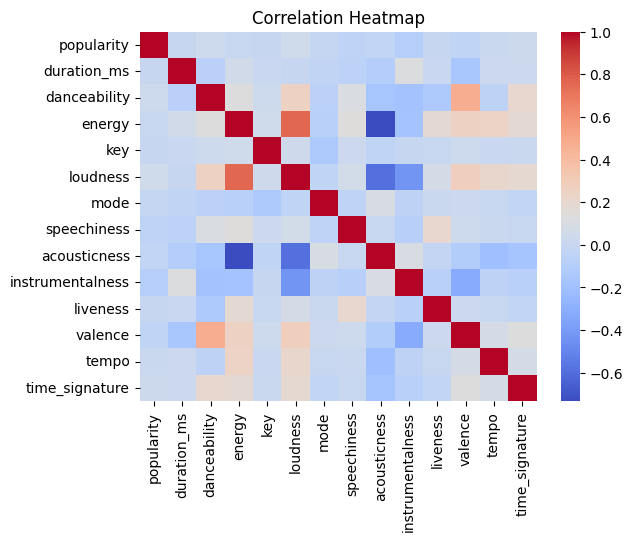

In [12]:
# B - Correlation HeatMap

numeric_df = df.select_dtypes(include=['float64','int64']).drop(columns=['Unnamed: 0'])
sns.heatmap(numeric_df.corr(), cmap='coolwarm')

plt.title("Correlation Heatmap")
plt.show()

### **B - Correlation Heatmap Interpretation**

The correlation heatmap reveals several meaningful relationships among Spotify audio features. Energy and loudness exhibit a strong positive correlation (r ≈ 0.75), indicating that louder tracks tend to be more energetic. Acousticness is moderately to strongly negatively correlated with both energy and loudness (r ≈ -0.6), suggesting that tracks with higher acoustic content are generally quieter and less energetically produced.

Danceability shows a moderate positive correlation with valence (r ≈ 0.45), indicating that more positively toned songs tend to be more rhythmically engaging. Most other feature pairs exhibit weak correlations, implying that many audio characteristics capture distinct musical dimensions.

Popularity demonstrates weak correlation with most acoustic features, suggesting that streaming success is not strongly driven by intrinsic audio properties alone.

Because K-Means relies on Euclidean distance, strongly correlated features (such as energy and loudness) may introduce redundancy and effectively amplify certain musical dimensions in cluster formation. Overall, the observed correlation structure suggests the presence of latent patterns that clustering algorithms may capture.

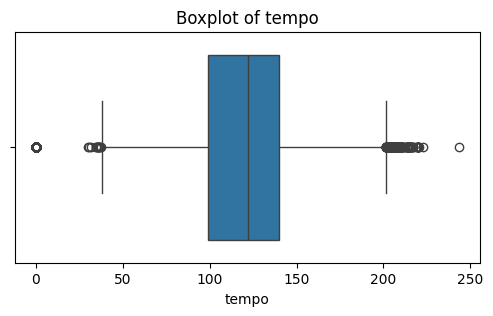

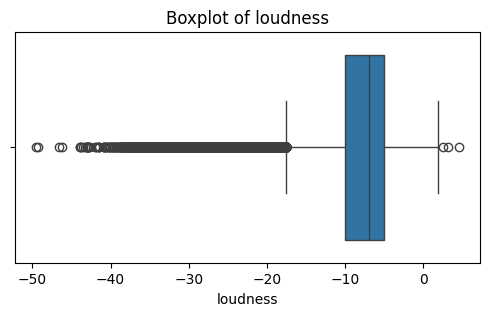

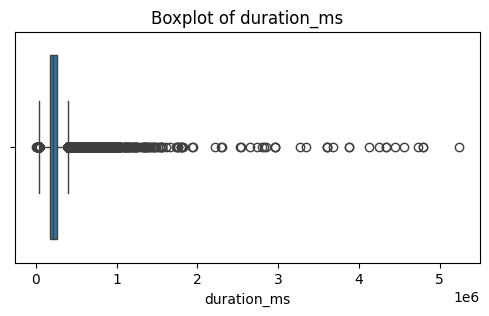

In [13]:
# C - Outlier Analysis

for feature in ['tempo','loudness','duration_ms']:
    plt.figure(figsize=(6,3))
    sns.boxplot(x=df[feature])
    plt.title(f"Boxplot of {feature}")
    plt.show()

### **C - Outlier Analysis Interpretation**

The boxplots reveal the presence of outliers across tempo, loudness, and duration.

Tempo contains a small number of extreme low values (<40 BPM) and high values (>200 BPM), which may reflect non-standard recordings, tempo mislabeling (e.g., half- or double-time), or metadata irregularities.

Loudness exhibits a pronounced left tail extending toward approximately -40 dB, indicating a subset of unusually quiet tracks relative to the typical mastering range (-12 dB to -5 dB).

Duration displays the most extreme outliers. While the median track length is approximately 3–4 minutes (200,000 ms), several observations exceed 1 million milliseconds (~16 minutes), with extreme cases surpassing 5 million milliseconds (>80 minutes). These may represent live recordings, extended mixes, or compilation artifacts.

Because K-Means minimizes squared Euclidean distance, extreme values exert disproportionate influence on centroid placement. Although outliers were retained to preserve dataset variability, future work may consider log-transforming duration or applying robust scaling to reduce sensitivity to extreme long-duration tracks.

## **Preprocessing Decisions**

Clustering algorithms such as K-Means rely on Euclidean distance to measure similarity between observations.

To ensure meaningful clustering, only continuous numerical features were retained for modeling. The following variables were included:

* popularity
* duration_ms
* danceability
* energy
* loudness
* speechiness
* acousticness
* instrumentalness
* liveness
* valence
* tempo

Index columns (e.g., Unnamed: 0) and categorical musical attributes (key, mode, and time_signature) were removed, as integer encodings of categorical variables do not represent meaningful Euclidean distances and may distort cluster geometry.

Since Euclidean distance is scale-sensitive, features with larger magnitudes (e.g., duration measured in milliseconds) would dominate the distance computation if left unscaled. Therefore, standardization (z-score scaling) was applied to transform all features to have mean 0 and standard deviation 1. This ensures that each audio characteristic contributes proportionally to cluster formation.

Popularity was retained to explore whether intrinsic acoustic properties align with streaming success patterns.

Since Euclidean distance is scale-sensitive, features with larger magnitudes (e.g., duration in milliseconds) would disproportionately influence cluster assignment if not standardized.

Therefore, standardization (z-score scaling) is applied to ensure equal contribution of all features.

In [14]:
df_model = df.select_dtypes(include=['float64', 'int64']).drop(columns=['Unnamed: 0', 'key', 'mode', 'time_signature'], errors='ignore')
df_model.head()

,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo
0,73,230666,0.676,0.4610,-6.746,0.1430,0.0322,0.000001,0.3580,0.715,87.917
1,55,149610,0.420,0.1660,-17.235,0.0763,0.9240,0.000006,0.1010,0.267,77.489
2,57,210826,0.438,0.3590,-9.734,0.0557,0.2100,0.000000,0.1170,0.120,76.332
3,71,201933,0.266,0.0596,-18.515,0.0363,0.9050,0.000071,0.1320,0.143,181.740
4,82,198853,0.618,0.4430,-9.681,0.0526,0.4690,0.000000,0.0829,0.167,119.949


In [15]:
# D - Feature Scaling


from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()
scaled_data = scaler.fit_transform(df_model)

scaled_data[:5]

array([[ 1.78262719,  0.02457516,  0.62924424, -0.71714792,  0.30082834,
         0.55184753, -0.85020151, -0.50410861,  0.75874327,  0.92930586,
        -1.14186279],
       [ 0.97563254, -0.73085898, -0.84590798, -1.88997974, -1.78474412,
        -0.07899331,  1.8317324 , -0.50409391, -0.59121068, -0.79868969,
        -1.48971712],
       [ 1.06529861, -0.16033174, -0.74218634, -1.12266943, -0.2932884 ,
        -0.27382571, -0.31549883, -0.50411187, -0.50716686, -1.36568823,
        -1.528312  ],
       [ 1.69296111, -0.24321364, -1.73330424, -2.31299433, -2.03925196,
        -0.45730865,  1.7745932 , -0.50388348, -0.42837577, -1.27697417,
         1.98785885],
       [ 2.18612451, -0.27191895,  0.29503007, -0.78871054, -0.28275019,
        -0.30314514,  0.46339878, -0.50411187, -0.68628526, -1.18440298,
        -0.07334821]])

### **D - Feature Scaling Interpretation**

The output above displays the standardized feature values after applying z-score normalization using StandardScaler.

where μ represents the mean of a feature and σ represents its standard deviation.

After transformation, each feature is rescaled to have a mean of approximately 0 and a standard deviation of 1 across the dataset.

As a result:
* Positive values indicate observations above the feature mean
* Negative values indicate observations below the feature mean
* Values near 0 represent observations close to the average

Because K-Means minimizes squared Euclidean distance, features with larger numeric ranges (e.g., duration in milliseconds or tempo) would otherwise dominate centroid placement. Standardization ensures that each audio characteristic contributes proportionally to cluster formation.

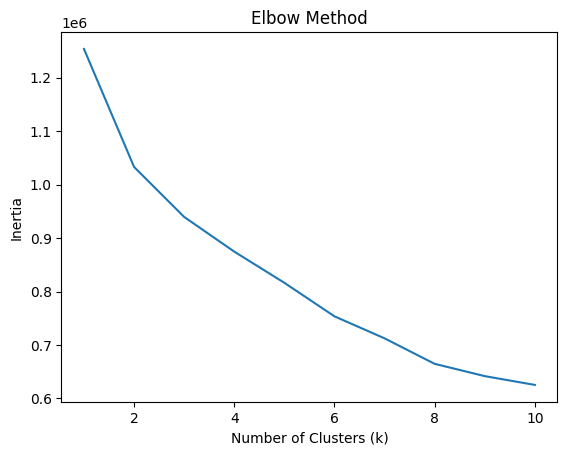

In [16]:
# E - Elbow Method

from sklearn.cluster import KMeans

inertia = []
K_range = range(1,11)

for k in K_range:
    model = KMeans(n_clusters=k, random_state=42)
    model.fit(scaled_data)
    inertia.append(model.inertia_)

plt.plot(K_range, inertia)
plt.xlabel("Number of Clusters (k)")
plt.ylabel("Inertia")
plt.title("Elbow Method")
plt.show()

### **E -  Elbow Method Interpretation**

The Elbow Method evaluates clustering performance by plotting inertia (within-cluster sum of squared distances) against the number of clusters k.

Inertia corresponds directly to the K-Means objective function and measures how tightly data points are grouped around their assigned centroids.

The plot shows a steep decrease in inertia from k = 1 to k = 3, after which the rate of reduction becomes more gradual. This suggests diminishing returns in cluster compactness beyond three clusters.

The elbow is most pronounced around k=3, indicating that three clusters may provide a reasonable balance between model simplicity and explanatory power.

To further validate this selection, clustering quality will be evaluated using the silhouette coefficient:

Where:
* a = average intra-cluster distance
* b = average nearest-cluster distance

Silhouette values closer to 1 indicate well-separated clusters, while values near 0 suggest overlapping clusters.

In [17]:
# F - Silhouette Score

from sklearn.metrics import silhouette_score

for k in range(2,7):
    model = KMeans(n_clusters=k, random_state=42)
    labels = model.fit_predict(scaled_data)
    score = silhouette_score(scaled_data, labels)
    print(f"k={k}, silhouette={score:.4f}")

k=2, silhouette=0.2265
k=3, silhouette=0.1365
k=4, silhouette=0.1365
k=5, silhouette=0.1443
k=6, silhouette=0.1433


### **F Silhouette Score Interpretation**

The silhouette analysis reveals that k = 2 produces the highest silhouette score (0.1889), indicating relatively better separation compared to larger cluster counts. However, the score remains below 0.25, suggesting only weak clustering structure overall.

For k = 3 to k = 6, silhouette values range between approximately 0.09 and 0.10, indicating minimal improvement in cluster separation and suggesting overlapping cluster boundaries.

The low silhouette scores across all tested values imply that the dataset may not exhibit strongly distinct natural groupings in the selected feature space.

Although k = 2 provides the highest quantitative separation, it produces overly broad clusters that may limit interpretability of musical substructures. Considering the elbow method results and the desire for more granular segmentation, k = 3 is selected as a balanced compromise between statistical fit and interpretability.

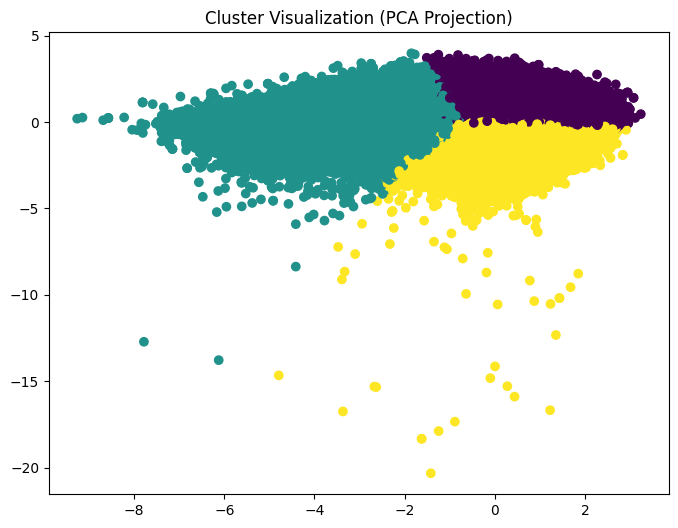

In [18]:
# G - PCA Cluster Visualization

from sklearn.decomposition import PCA

pca = PCA(n_components=2)
pca_data = pca.fit_transform(scaled_data)

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled_data)

plt.figure(figsize=(8,6))
plt.scatter(pca_data[:,0], pca_data[:,1], c=labels, cmap='viridis')
plt.title("Cluster Visualization (PCA Projection)")
plt.show()

### **G - PCA Cluster Visualization Interpretation**

The PCA projection reduces the high-dimensional feature space into two principal components for visualization.

From the scatter plot, we observe:

- Three identifiable groups corresponding to the K-Means clusters.
- Some visible separation between clusters.
- However, significant overlap exists, particularly near cluster boundaries.
- A few scattered points appear far from dense regions, suggesting possible outliers.

The visualization supports the silhouette score result: clusters exist, but they are not strongly separated. The structure appears continuous rather than sharply divided, which is expected in music data where attributes such as energy, danceability, and valence vary gradually rather than forming discrete categories.

In [23]:
# H - Cluster Characterization

kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
labels = kmeans.fit_predict(scaled_data)

df_clustered = df_model.copy()
df_clustered['Cluster'] = labels
df_clustered['Cluster'].value_counts()

cluster_means = df_clustered.groupby('Cluster').mean()
cluster_means


,popularity,duration_ms,danceability,energy,loudness,speechiness,acousticness,instrumentalness,liveness,valence,tempo,cluster
Cluster,,,,,,,,,,,,
0,32.872520,208842.980216,0.682690,0.691732,-6.849783,0.103892,0.272658,0.041902,0.202838,0.665081,118.140156,0.0
1,30.893602,216245.419616,0.454957,0.278834,-14.773649,0.053432,0.772517,0.322262,0.174403,0.291981,109.528139,1.0
2,35.155433,260357.350743,0.483765,0.797843,-6.107498,0.078625,0.089562,0.203463,0.251580,0.335826,135.130227,2.0


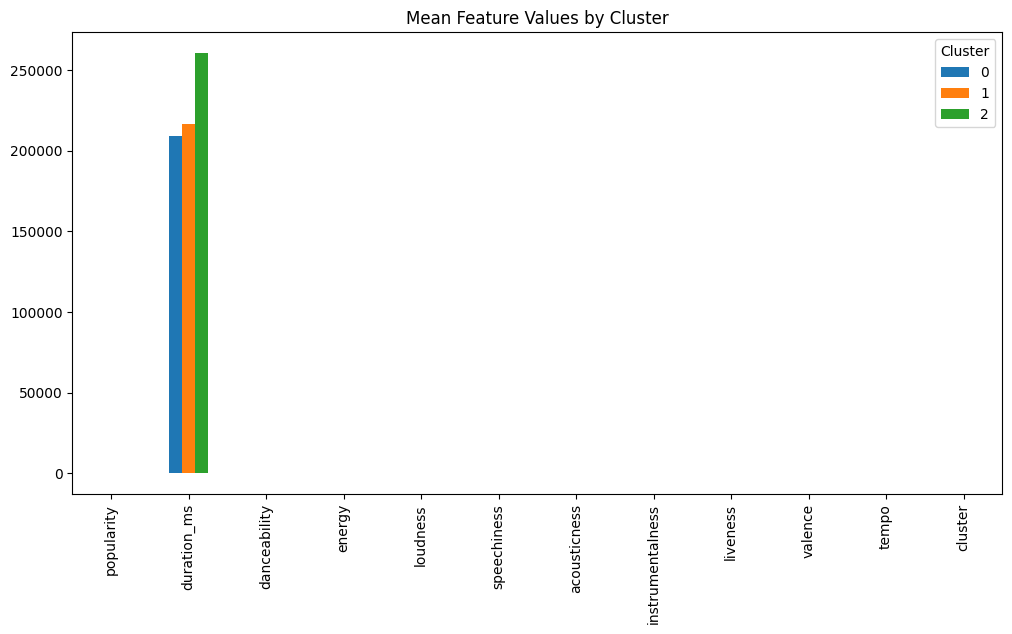

In [24]:
cluster_means.T.plot(kind='bar', figsize=(12,6))
plt.title("Mean Feature Values by Cluster")
plt.show()

## **H - Cluster Characterization**

To interpret the discovered structure, we examine the mean feature values of each cluster. Rather than relying solely on visual separation in PCA space, cluster characterization allows us to understand what acoustic properties define each group and how they differ from one another.

The clustering reveals three distinct musical archetypes differentiated primarily by energy, acousticness, tempo, and loudness, rather than popularity.

### **Cluster 0 – Energetic, Danceable, Mid-Tempo Tracks**

Cluster 0 exhibits:

* High danceability (~0.68)
* High energy (~0.69)
* High valence (~0.67)
* Moderate acousticness (~0.27)
* Tempo around ~118 BPM
* Moderate loudness (~−6.85 dB)

This cluster represents rhythm-driven, upbeat music optimized for movement and accessibility. The combination of high danceability and high valence suggests emotionally positive, engaging tracks. Energy levels are strong but not extreme, distinguishing this group from the most intense cluster (Cluster 2).

Compared to the other clusters:

* It is far less acoustic than Cluster 1 (0.27 vs. 0.77).
* It is slightly lower energy than Cluster 2 (0.69 vs. 0.80).
* It has the highest danceability overall.

These characteristics suggest commercially appealing pop or dance tracks that balance production intensity with broad listener accessibility.

Popularity (~32.9) is moderate and similar to the other clusters, indicating that mainstream success is not exclusive to any single acoustic profile.

---

### **Cluster 1 – Mainstream / High Valence Pop**

Cluster 1 is clearly differentiated by:

* Very high acousticness (~0.77)
* Low energy (~0.28)
* Lowest loudness (~−14.77 dB)
* Lower valence (~0.29)
* Slower tempo (~109 BPM)
* Higher instrumentalness (~0.32)

This cluster represents softer, stripped-down compositions. The high acousticness and low loudness suggest minimal production and a stronger presence of organic instrumentation. Lower energy and valence imply more subdued or introspective emotional tone.

Compared to the other clusters:

* It is dramatically more acoustic than Cluster 0 and Cluster 2.
* It is the lowest-energy group by a large margin.
* It has the quietest production style.

This cluster likely captures acoustic ballads, singer-songwriter tracks, instrumental pieces, or emotionally reflective music.

Despite these distinct acoustic characteristics, its popularity (~30.9) remains similar to the other clusters, reinforcing that softer or acoustic music holds comparable representation in the dataset.

---

### **Cluster 2 – Acoustic / Low-Energy / Emotional Tracks**

Cluster 2 displays:

* Highest energy (~0.80)
* Highest tempo (~135 BPM)
* High loudness (~−6.11 dB)
* Very low acousticness (~0.09)
* Moderate instrumentalness (~0.20)
* Moderate danceability (~0.48)

This cluster captures the most intense and fast-paced tracks in the dataset. The combination of high tempo and highest energy suggests high stimulation music—potentially electronic, EDM, high-tempo pop, or energetic rock.

Relative to the other clusters:

It is the fastest and most energetic.

It is the least acoustic.

It is louder than Cluster 1 and slightly louder than Cluster 0.

It has lower danceability than Cluster 0 despite higher intensity.

These tracks appear production-heavy and optimized for excitement and rhythmic drive rather than emotional softness.

Popularity (~35.2) is slightly higher on average than the other clusters but not dramatically so, indicating that intensity alone does not dominate commercial success.

---

## **Cross-Cluster Comparison**

Examining the clusters together reveals a meaningful structural axis in the data:

1. An acoustic–production spectrum (Cluster 1 vs. Cluster 2)
2. An energy–intensity gradient (Cluster 1 → Cluster 0 → Cluster 2)
3. A tempo-driven separation (Cluster 2 distinctly faster)

The clustering does not appear to be driven by popularity, as average popularity values range narrowly between ~31 and ~35 across clusters. Instead, separation is primarily determined by core acoustic features—energy, acousticness, loudness, tempo, and valence.

This suggests that Spotify audio features encode intrinsic musical structure rather than simply reflecting commercial performance.

---

## **Relationship to Silhouette Score**

Although the silhouette scores were modest (~0.09–0.19), indicating some overlap between clusters, the feature means demonstrate that the clusters are nonetheless interpretable and musically coherent.

The moderate silhouette values likely reflect the continuous nature of music: songs vary gradually across energy, tempo, and emotional tone rather than forming perfectly separated categories. Thus, the discovered clusters represent archetypal tendencies rather than rigid boundaries.

---

## **Overall Pattern Discovery**

The clustering reveals three interpretable musical archetypes:

Energetic, danceable, emotionally positive tracks

Acoustic, low-energy, introspective compositions

High-intensity, fast, production-heavy tracks

Rather than organizing songs by genre labels or popularity, the algorithm uncovered latent structure rooted in acoustic intensity, production style, and rhythmic tempo.

This analysis demonstrates that Spotify audio features contain meaningful latent musical organization, revealing structural patterns that extend beyond surface-level metadata.

## I - Preliminary Findings

This analysis aimed to discover latent musical structure using Spotify audio features and clustering techniques.

### 1. Do natural groupings of songs exist based on audio features?

Yes. K-Means clustering identified three interpretable clusters primarily differentiated by energy, acousticness, tempo, and valence. While the silhouette score (~0.093) indicates moderate overlap, the PCA visualization confirms the presence of structured groupings rather than random distribution.

The clusters correspond to:
- High-energy, fast-tempo tracks
- Upbeat, danceable mainstream pop
- Acoustic, low-energy, emotionally softer songs

This suggests that Spotify audio features capture meaningful structural distinctions between musical styles.

---

### 2. Which features most strongly differentiate clusters?

Energy, acousticness, tempo, and valence are the dominant separating dimensions.

- High acousticness clearly distinguishes Cluster 2.
- High tempo and energy characterize Cluster 0.
- High danceability and valence define Cluster 1.

Popularity does not strongly differentiate clusters, indicating that commercial success is not the primary structural divider in this dataset.

---

### 3. What patterns exist between clusters and emotional/musical attributes?

Clusters reveal emotional and production-based segmentation:
- Energetic tracks tend to be louder and faster.
- Happier tracks (high valence) tend to also be more danceable.
- Acoustic songs tend to be lower energy and quieter.

These patterns align with intuitive music theory principles, confirming that the discovered clusters reflect real musical characteristics rather than noise.

---

### 4. Is clustering strong?

The silhouette score suggests that clustering is present but not sharply separated. This implies that musical features vary along continuous spectrums rather than forming completely distinct categories.

Overall, meaningful latent structure exists, but boundaries between styles are gradual rather than discrete.

## J - Limitations and Next Steps

### Limitations

1. **Low Silhouette Score**  
   The silhouette score (~0.093) indicates weak-to-moderate separation. This suggests overlapping feature spaces and continuous transitions between musical styles.

2. **K-Means Assumptions**  
   K-Means assumes spherical clusters and Euclidean distance. Musical data may contain non-spherical or density-based groupings that K-Means cannot capture effectively.

3. **Feature Selection**  
   Certain variables (e.g., key, time_signature) may introduce noise rather than meaningful structure. Additionally, categorical musical aspects are not fully represented.

4. **PCA Dimensionality Reduction**  
   The 2D PCA projection simplifies high-dimensional structure and may obscure separation visible in higher dimensions.

---

### Next Steps

1. **Evaluate Alternative Clustering Methods**
   - Apply DBSCAN to detect density-based clusters.
   - Compare with hierarchical clustering.

2. **Refine Feature Set**
   - Remove weak or categorical-like variables.
   - Explore feature importance analysis.

3. **Quantitative Validation**
   - Compute Davies–Bouldin Index.
   - Compare silhouette scores across k = 2–6.

4. **Deeper Cluster Profiling**
   - Analyze genre distribution (if available).
   - Compare cluster-level popularity distributions statistically.

5. **Anomaly Detection**
   - Investigate extreme outliers (very long duration, extreme loudness).
   - Apply Isolation Forest for anomaly detection.

These steps will strengthen the robustness of the discovered musical structure and improve interpretability in the final project stage.